# Figure cb - Multi-Phenotype Epistasis Heatmap

This script plots a multi-phenotype heatmap, which displays the additive epistatic coefficients for each Omi32 mutation and the absolute sum of all higher-order interactions that each mutation is involved in for the reference-based framework.

- Additive coefficients are only colored if they are significant by bonferroni-corrected p-value
- For higher-order absolute sums, a coefficient is only included in the absolute sum if it is significant by bonferroni-corrected p-value
- the base p-value requirement for significance is 0.05, so the bonferroni-corrected p-value must be below 0.05 divided by the number of coefficients inferred for each model in order for an individual coefficient to be considered significant (this is calculated during the epistasis inference in `epistasis_inference/linear_interaction_models` for each phenotype)


Loading phenotype data...
Loading wuhan_affinity: ../../epistasis_inference/linear_interaction_models/wuhan/reference-based/model_coeffs/wuhan_raw_2order_full_biochem.txt (order 2)
  29 sig (10 first, 19 higher)
✓ Wuhan affinity (R²=0.814)
Loading ba1_affinity: ../../epistasis_inference/linear_interaction_models/ba1/reference-based/model_coeffs/ba1_raw_3order_full_biochem.txt (order 3)
  37 sig (7 first, 30 higher)
✓ BA.1 affinity (R²=0.823)
Loading ba4_affinity: ../../epistasis_inference/linear_interaction_models/ba4/reference-based/model_coeffs/ba4_raw_3order_full_biochem.txt (order 3)
  42 sig (4 first, 38 higher)
✓ BA.4 affinity (R²=0.880)
Loading expression: ../../epistasis_inference/linear_interaction_models/expression/reference-based/model_coeffs/expression_raw_2order_full_biochem.txt (order 2)
  24 sig (5 first, 19 higher)
✓ expression (R²=0.346)
Loading psr: ../../epistasis_inference/linear_interaction_models/psr/reference-based/model_coeffs/psr_raw_2order_full_biochem.txt (o

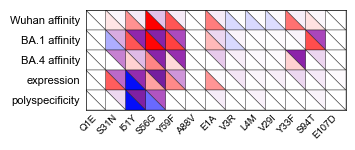

Saved: Figure_4cFigure_4c_colorbar_first_order.png


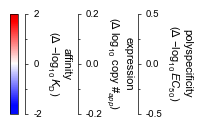

Saved: Figure_4cFigure_4c_colorbar_higher_order.png


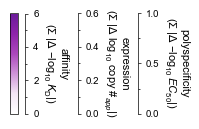


✅ Saved to: Figure_4c.png


In [2]:
import os
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
import seaborn as sns
from typing import Dict, List, Tuple, Optional

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'
plt.rcParams.update({'axes.linewidth': 0.5,
    'xtick.major.size': 2, 'ytick.major.size': 2,
    'xtick.major.pad': 2, 'ytick.major.pad': 4})

PHENOTYPE_CONFIGS = {
    'wuhan_affinity': {'file_path': '../../epistasis_inference/linear_interaction_models/wuhan/reference-based/model_coeffs/wuhan_raw_2order_full_biochem.txt', 'order': 2, 'display_name': 'Wuhan affinity'},
    'ba1_affinity':   {'file_path': '../../epistasis_inference/linear_interaction_models/ba1/reference-based/model_coeffs/ba1_raw_3order_full_biochem.txt',     'order': 3, 'display_name': 'BA.1 affinity'},
    'ba4_affinity':   {'file_path': '../../epistasis_inference/linear_interaction_models/ba4/reference-based/model_coeffs/ba4_raw_3order_full_biochem.txt',     'order': 3, 'display_name': 'BA.4 affinity'},
    'expression':     {'file_path': '../../epistasis_inference/linear_interaction_models/expression/reference-based/model_coeffs/expression_raw_2order_full_biochem.txt', 'order': 2, 'display_name': 'expression'},
    'psr':            {'file_path': '../../epistasis_inference/linear_interaction_models/psr/reference-based/model_coeffs/psr_raw_2order_full_biochem.txt',     'order': 2, 'display_name': 'polyspecificity'},
}

NUM_MUTATIONS  = 13
N_PHENOTYPES   = len(PHENOTYPE_CONFIGS) 

CELL_SIZE = 0.2   

LEFT_MARGIN   = 0.8
RIGHT_MARGIN  = 0.2
TOP_MARGIN    = 0.2
BOTTOM_MARGIN = 0.6

COLORBAR_CANVAS_WIDTH  = 0.075
COLORBAR_CANVAS_HEIGHT = 1.0

COLORBAR_LEFT_MARGIN   = 0.1
COLORBAR_RIGHT_MARGIN  = 1.0
COLORBAR_TOP_MARGIN    = 0.1
COLORBAR_BOTTOM_MARGIN = 0.1

def create_seismic_bright_blue():
    seismic = plt.colormaps['seismic']
    n = 256
    colors = seismic(np.linspace(0, 1, n))
    for i in range(int(n * 0.3)):
        pos = i / (n * 0.3)
        r, g, b, a = colors[i]
        bb = (1 - pos) * 0.5
        colors[i] = [min(1.0, r + bb*0.1), min(1.0, g + bb*0.3), min(1.0, b + bb*0.7), a]
    return LinearSegmentedColormap.from_list('seismic_bright_blue', colors)

def create_bright_purple_cmap():
    return LinearSegmentedColormap.from_list('bright_purple',
        ['#FFFFFF', '#F3E5F5', '#CE93D8', '#AB47BC', '#8E24AA', '#6A1B9A'], N=256)

FIRST_ORDER_CMAP     = create_seismic_bright_blue()
HIGHER_ORDER_CMAP    = create_bright_purple_cmap()
FIRST_ORDER_TRUNCATE = (0.2, 0.8)
HIGHER_ORDER_TRUNCATE = None

COLOR_RANGES = {
    'affinity':   (-2.0, 2.0),
    'expression': (-0.2, 0.2),
    'psr':        (-0.5, 0.5),
}
HIGHER_ORDER_RANGES = {
    'affinity':   (0, 6.0),
    'expression': (0, 0.6),
    'psr':        (0, 1.0),
}

# for mutation labels given in Tharp et al, 2026, subtract 19 from the position number for each mutation (for both heavy and light chain mutations)
ORIGINAL_MUTATION_LABELS = ['Q20E','S50N','I70Y','S75G','Y78F','A107V',
                             'E20A','V22R','L23M','V48I','Y52F','S113T','E126D']

def convert_mutation_label(label):
    import re
    match = re.match(r'([A-Z])(\d+)([A-Z])', label)
    if match:
        aa1, pos, aa2 = match.groups()
        return f'{aa1}{int(pos)-19}{aa2}'
    return label

MUTATION_LABELS = [convert_mutation_label(l) for l in ORIGINAL_MUTATION_LABELS]

def load_coefficients(filepath):
    if not os.path.exists(filepath):
        raise FileNotFoundError(filepath)
    names, coefs, stderr, pvals, cis, sig = [], [], [], [], [], []
    with open(filepath, 'r') as f:
        reader = csv.reader(f, delimiter='\t')
        n_params   = int(next(reader)[1])
        r2         = float(next(reader)[1])
        alpha      = float(next(reader)[1])
        alpha_bonf = float(next(reader)[1])
        next(reader)
        for row in reader:
            if len(row) < 6: continue
            term, coef, se, pval, ci_l, ci_u = (
                row[0], float(row[1]), float(row[2]),
                float(row[3]), float(row[4]), float(row[5]))

            # Bonferroni significance
            is_sig = (term != "Intercept" and pval < alpha_bonf)
            names.append(term); coefs.append(coef); stderr.append(se)
            pvals.append(pval); cis.append((ci_l, ci_u)); sig.append(is_sig)
    return {
        'names': names, 'coefs': coefs, 'stderr': stderr,
        'pvals': pvals, 'cis': cis, 'sig': sig,
        'r2': r2, 'n_params': n_params,
        'alpha': alpha, 'alpha_bonf': alpha_bonf,
    }

def extract_mutation_effects(coef_data, num_mutations):
    first_order       = np.zeros(num_mutations)
    higher_order_sums = np.zeros(num_mutations)
    sig_count = first_order_count = higher_order_count = 0
    for name, coef, is_sig in zip(coef_data['names'], coef_data['coefs'], coef_data['sig']):
        if not is_sig or name == 'Intercept': continue
        sig_count += 1
        try: indices = [int(x) - 1 for x in name.split(',')]
        except: continue
        indices = [idx for idx in indices if 0 <= idx < num_mutations]
        if len(indices) == 1:
            first_order[indices[0]] = coef; first_order_count += 1
        elif len(indices) >= 2:
            for idx in indices: higher_order_sums[idx] += abs(coef)
            higher_order_count += 1
    print(f"  {sig_count} sig ({first_order_count} first, {higher_order_count} higher)")
    return {'first_order': first_order, 'higher_order': higher_order_sums}

def load_phenotype_data(phenotype, config):
    print(f"Loading {phenotype}: {config['file_path']} (order {config['order']})")
    if not os.path.exists(config['file_path']): raise FileNotFoundError(config['file_path'])
    coef_data = load_coefficients(config['file_path'])
    effects   = extract_mutation_effects(coef_data, NUM_MUTATIONS)
    return {
        'effects':      effects,
        'order':        config['order'],
        'r2':           coef_data['r2'],
        'alpha':        coef_data['alpha'],
        'alpha_bonf':   coef_data['alpha_bonf'],
        'display_name': config['display_name'],
    }

def plot_split_triangle_heatmap(phenotype_data, phenotype_configs, mutation_labels, output_path):
    phenotypes   = list(phenotype_data.keys())
    n_phenotypes = len(phenotypes)
    n_mutations  = len(mutation_labels)

    canvas_w = n_mutations  * CELL_SIZE
    canvas_h = n_phenotypes * CELL_SIZE

    fig_width  = LEFT_MARGIN + canvas_w + RIGHT_MARGIN
    fig_height = TOP_MARGIN  + canvas_h + BOTTOM_MARGIN

    def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
        name = cmap.name if hasattr(cmap, 'name') else 'custom'
        return LinearSegmentedColormap.from_list(
            f'trunc({name},{minval:.2f},{maxval:.2f})',
            cmap(np.linspace(minval, maxval, n)))

    def get_cmap(cmap_obj, truncate=None):
        if isinstance(cmap_obj, str):
            cmap = (sns.color_palette(cmap_obj, as_cmap=True)
                    if cmap_obj in dir(sns) else plt.colormaps[cmap_obj])
        else:
            cmap = cmap_obj
        return truncate_colormap(cmap, *truncate) if truncate else cmap

    first_cmap  = get_cmap(FIRST_ORDER_CMAP,  FIRST_ORDER_TRUNCATE)
    higher_cmap = get_cmap(HIGHER_ORDER_CMAP, HIGHER_ORDER_TRUNCATE)

    def get_first_order_range(p):
        if 'expression' in p.lower(): return COLOR_RANGES['expression']
        if 'psr' in p.lower() or 'reactivity' in p.lower(): return COLOR_RANGES['psr']
        return COLOR_RANGES['affinity']

    def get_higher_order_range(p):
        if 'expression' in p.lower(): return HIGHER_ORDER_RANGES['expression']
        if 'psr' in p.lower() or 'reactivity' in p.lower(): return HIGHER_ORDER_RANGES['psr']
        return HIGHER_ORDER_RANGES['affinity']

    fig = plt.figure(figsize=(fig_width, fig_height))
    gs  = GridSpec(1, 1, figure=fig,
                   left   = LEFT_MARGIN / fig_width,
                   right  = (LEFT_MARGIN + canvas_w) / fig_width,
                   top    = 1 - TOP_MARGIN / fig_height,
                   bottom = BOTTOM_MARGIN / fig_height)
    ax = fig.add_subplot(gs[0])

    for i, phenotype in enumerate(phenotypes):
        effects             = phenotype_data[phenotype]['effects']
        first_order_range   = get_first_order_range(phenotype)
        higher_order_range  = get_higher_order_range(phenotype)
        y_bottom, y_top     = i * CELL_SIZE, (i + 1) * CELL_SIZE

        for j in range(n_mutations):
            first_val  = effects['first_order'][j]
            higher_val = effects['higher_order'][j]
            first_is_sig  = abs(first_val)  > 1e-10
            higher_is_sig = abs(higher_val) > 1e-10

            if first_is_sig:
                fc = np.clip(first_val, *first_order_range)
                fn = (fc - first_order_range[0]) / (first_order_range[1] - first_order_range[0])
                first_color = first_cmap(fn)
            else:
                first_color = 'white'

            if higher_is_sig:
                hc = np.clip(higher_val, *higher_order_range)
                hn = (hc - higher_order_range[0]) / (higher_order_range[1] - higher_order_range[0])
                higher_color = higher_cmap(np.clip(hn, 0, 1))
            else:
                higher_color = 'white'

            x0, x1 = j * CELL_SIZE, (j + 1) * CELL_SIZE

            # Upper-left triangle: first-order
            ax.add_patch(patches.Polygon(
                [(x0, y_bottom), (x1, y_top), (x0, y_top)],
                facecolor=first_color, edgecolor='black', linewidth=0.25))
            # Lower-right triangle: higher-order
            ax.add_patch(patches.Polygon(
                [(x0, y_bottom), (x1, y_bottom), (x1, y_top)],
                facecolor=higher_color, edgecolor='black', linewidth=0.25))

    x_label_offset = CELL_SIZE * 0.15

    ax.set_xlim(0, n_mutations  * CELL_SIZE)
    ax.set_ylim(0, n_phenotypes * CELL_SIZE)
    ax.set_xticks(np.arange(n_mutations)  * CELL_SIZE + CELL_SIZE * 0.5 + x_label_offset)
    ax.set_xticklabels(mutation_labels, fontsize=7, rotation=45, ha='right')
    ax.set_yticks(np.arange(n_phenotypes) * CELL_SIZE + CELL_SIZE * 0.5)
    ax.set_yticklabels([phenotype_data[p]['display_name'] for p in phenotypes], fontsize=8)
    ax.invert_yaxis()
    ax.tick_params(axis='both', which='both', length=0)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)

    plt.savefig(output_path, dpi=2000, bbox_inches='tight', transparent=True)

    print(f"Saved: {output_path}")
    print(f"Canvas: {canvas_w:.2f} × {canvas_h:.2f} in  |  Figure: {fig_width:.2f} × {fig_height:.2f} in")
    print(f"At 2000 DPI: {int(fig_width*2000)} × {int(fig_height*2000)} px")
    plt.show()

    # generate colorbars
    measurement_types = [
        {
            'name': 'affinity',
            'first_range':        COLOR_RANGES['affinity'],
            'higher_range':       HIGHER_ORDER_RANGES['affinity'],
            'first_label':        r'$\Delta$ $-\log_{10} K_{\mathrm{D}}$',
            'higher_label':       r'$\Sigma$ |$\Delta$ $-\log_{10} K_{\mathrm{D}}$|',
            'first_major_ticks':  [-2, 0, 2],
            'first_minor_ticks':  [-1, 1],
            'higher_major_ticks': [0, 2, 4, 6],
            'higher_minor_ticks': [1, 3, 5],
            'tick_format': '{:.0f}',
        },
        {
            'name': 'expression',
            'first_range':        COLOR_RANGES['expression'],
            'higher_range':       HIGHER_ORDER_RANGES['expression'],
            'first_label':        r'$\Delta$ log$_{10}$ copy #$_{\mathit{app}}$',
            'higher_label':       r'$\Sigma$ |$\Delta$ log$_{10}$ copy #$_{\mathit{app}}$|',
            'first_major_ticks':  [-0.2, 0, 0.2],
            'first_minor_ticks':  [-0.1, 0.1],
            'higher_major_ticks': [0, 0.2, 0.4, 0.6],
            'higher_minor_ticks': [0.1, 0.3, 0.5],
            'tick_format': '{:.1f}',
        },
        {
            'name': 'polyspecificity',
            'first_range':        COLOR_RANGES['psr'],
            'higher_range':       HIGHER_ORDER_RANGES['psr'],
            'first_label':        r'$\Delta$ $-\log_{10} \mathit{EC}_{\mathrm{50}}$',
            'higher_label':       r'$\Sigma$ |$\Delta$ $-\log_{10} \mathit{EC}_{\mathrm{50}}$|',
            'first_major_ticks':  [-0.5, 0, 0.5],
            'first_minor_ticks':  [-0.25, 0.25],
            'higher_major_ticks': [0, 0.5, 1.0],
            'higher_minor_ticks': [0.25, 0.75],
            'tick_format': '{:.1f}',
        },
    ]

    y_axis_positions = [2, 9, 17]

    cbar_fig_width  = COLORBAR_LEFT_MARGIN + COLORBAR_CANVAS_WIDTH + COLORBAR_RIGHT_MARGIN
    cbar_fig_height = COLORBAR_TOP_MARGIN  + COLORBAR_CANVAS_HEIGHT + COLORBAR_BOTTOM_MARGIN

    def make_colorbar_fig(path, sm, order_key, label_key, vmin, vmax, cmap):
        fig_cb = plt.figure(figsize=(cbar_fig_width, cbar_fig_height))
        gs_cb  = GridSpec(1, 1, figure=fig_cb,
                          left   = COLORBAR_LEFT_MARGIN / cbar_fig_width,
                          right  = (COLORBAR_LEFT_MARGIN + COLORBAR_CANVAS_WIDTH) / cbar_fig_width,
                          top    = 1 - COLORBAR_TOP_MARGIN / cbar_fig_height,
                          bottom = COLORBAR_BOTTOM_MARGIN / cbar_fig_height)
        ax_cb = fig_cb.add_subplot(gs_cb[0])
        cbar  = plt.colorbar(plt.cm.ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap),
                             cax=ax_cb, orientation='vertical')
        cbar.ax.set_ylabel('')
        cbar.set_ticks([])

        for mtype, pos in zip(measurement_types, y_axis_positions):
            ax_tw = ax_cb.twinx()
            ax_tw.spines['right'].set_position(('axes', pos))
            ax_tw.spines['right'].set_color('black')
            ax_tw.spines['right'].set_linewidth(0.5)
            ax_tw.spines['left'].set_visible(False)
            ax_tw.spines['top'].set_visible(False)
            ax_tw.spines['bottom'].set_visible(False)
            ax_tw.set_ylim(mtype[order_key + '_range'])
            ax_tw.set_yticks(mtype[order_key + '_major_ticks'])
            ax_tw.set_yticks(mtype[order_key + '_minor_ticks'], minor=True)
            ax_tw.tick_params(axis='y', which='major', labelsize=7, length=2, width=0.5, direction='out')
            ax_tw.tick_params(axis='y', which='minor', labelsize=0, length=1.5, width=0.5, direction='out')
            ax_tw.set_yticklabels([mtype['tick_format'].format(t) for t in mtype[order_key + '_major_ticks']])
            ax_tw.set_ylabel(f"{mtype['name']}\n({mtype[label_key]})",
                             fontsize=8, rotation=270, labelpad=2, va='bottom')

        plt.savefig(path, dpi=2000, bbox_inches='tight', transparent=True)
        
        print(f"Saved: {path}")
        plt.show()

    make_colorbar_fig(
        output_path.replace('.png', 'Figure_4c_colorbar_first_order.png'),
        None, 'first', 'first_label', -2.0, 2.0, first_cmap)

    make_colorbar_fig(
        output_path.replace('.png', 'Figure_4c_colorbar_higher_order.png'),
        None, 'higher', 'higher_label', 0, 6.0, higher_cmap)


# ── Entry point ────────────────────────────────────────────────
if __name__ == "__main__":
    print("\n" + "="*70)
    print("Loading phenotype data...")
    print("="*70)

    phenotype_data = {}
    for phenotype, config in PHENOTYPE_CONFIGS.items():
        try:
            phenotype_data[phenotype] = load_phenotype_data(phenotype, config)
            print(f"✓ {config['display_name']} (R²={phenotype_data[phenotype]['r2']:.3f})")
        except Exception as e:
            print(f"✗ Failed: {config['display_name']}: {e}")

    if phenotype_data:
        output_file = 'Figure_4c.png'
        plot_split_triangle_heatmap(phenotype_data, PHENOTYPE_CONFIGS, MUTATION_LABELS, output_file)
        print(f"\n✅ Saved to: {output_file}")